In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [13]:
df = pd.read_csv("../data/stores_sales_forecasting.csv", encoding="latin1")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [14]:
print("Shape of Dataset")
print(df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

Shape of Dataset
(2121, 21)

First 5 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092



Column Names
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          

In [15]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


In [16]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [17]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [18]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date Columns Converted")

Date Columns Converted


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2121 non-null   int64         
 1   Order ID       2121 non-null   object        
 2   Order Date     2121 non-null   datetime64[ns]
 3   Ship Date      2121 non-null   datetime64[ns]
 4   Ship Mode      2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  Postal Code    2121 non-null   int64         
 12  Region         2121 non-null   object        
 13  Product ID     2121 non-null   object        
 14  Category       2121 non-null   object        
 15  Sub-Category   2121 n

In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,Tuesday,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,Tuesday,4
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,Sunday,4
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,9,Monday,2
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,9,Monday,2


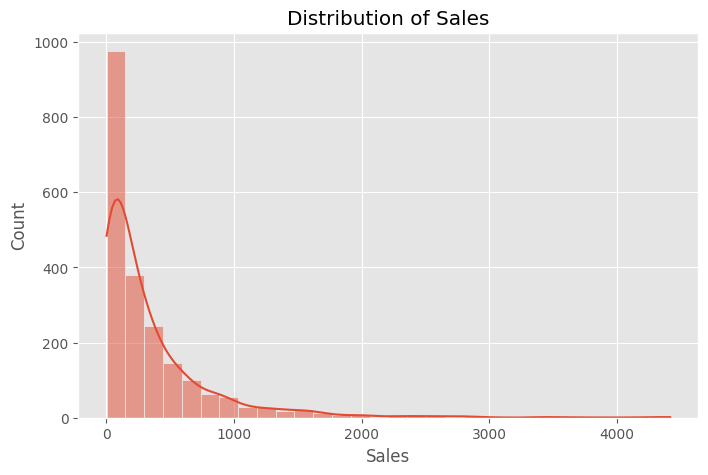

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")

plt.show()

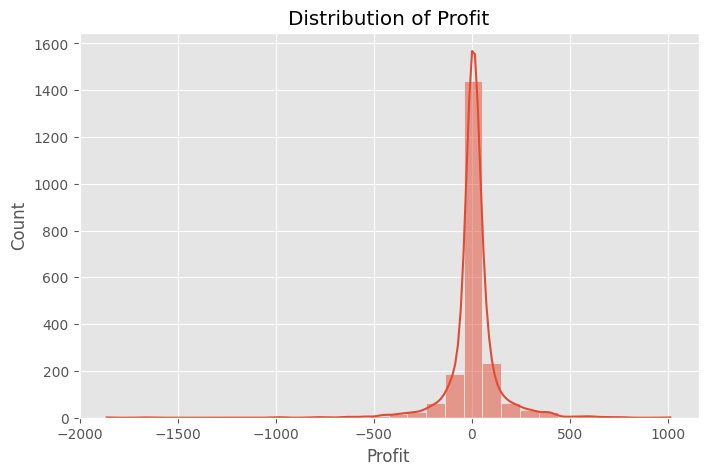

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Distribution of Profit")

plt.show()

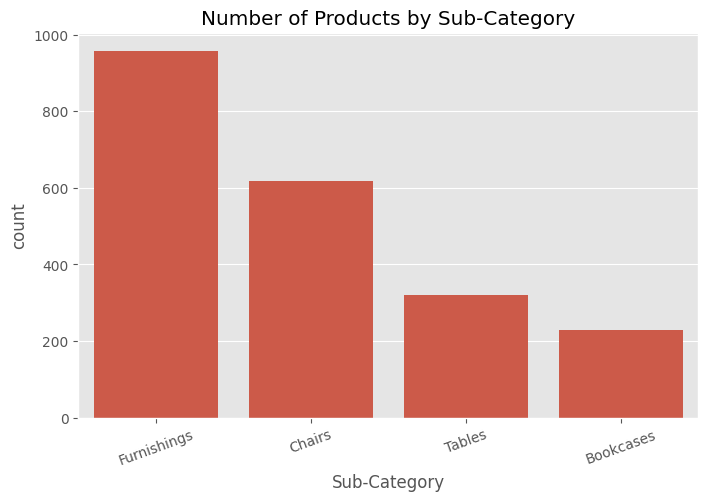

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sub-Category",
    order=df["Sub-Category"].value_counts().index
)

plt.title("Number of Products by Sub-Category")
plt.xticks(rotation=20)

plt.show()

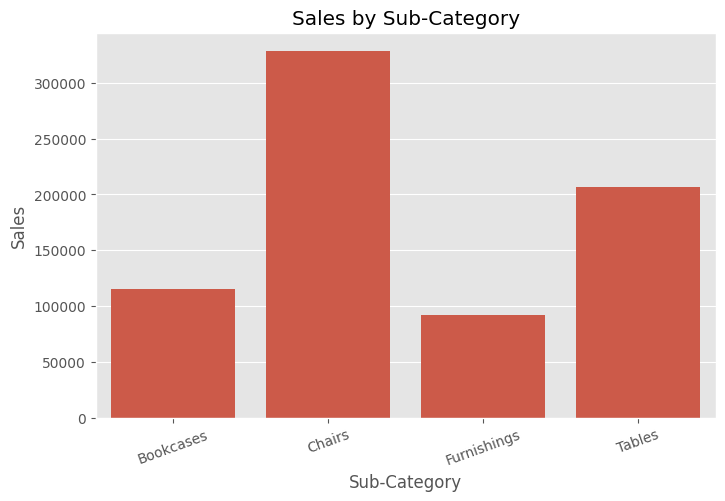

In [30]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=subcategory_sales,
    x="Sub-Category",
    y="Sales"
)

plt.title("Sales by Sub-Category")
plt.xticks(rotation=20)

plt.show()

In [26]:
print(df["Category"].unique())

['Furniture']


In [27]:
print(df["Category"].value_counts())

Category
Furniture    2121
Name: count, dtype: int64


In [28]:
print(df["Category"].unique())
print(df["Category"].value_counts())
print(df["Sub-Category"].unique())
print(df[["Category", "Sub-Category"]].head(20))

['Furniture']
Category
Furniture    2121
Name: count, dtype: int64
['Bookcases' 'Chairs' 'Tables' 'Furnishings']
     Category Sub-Category
0   Furniture    Bookcases
1   Furniture       Chairs
2   Furniture       Tables
3   Furniture  Furnishings
4   Furniture       Tables
5   Furniture       Chairs
6   Furniture       Tables
7   Furniture    Bookcases
8   Furniture  Furnishings
9   Furniture  Furnishings
10  Furniture    Bookcases
11  Furniture       Chairs
12  Furniture  Furnishings
13  Furniture       Chairs
14  Furniture       Chairs
15  Furniture  Furnishings
16  Furniture       Chairs
17  Furniture       Chairs
18  Furniture  Furnishings
19  Furniture  Furnishings


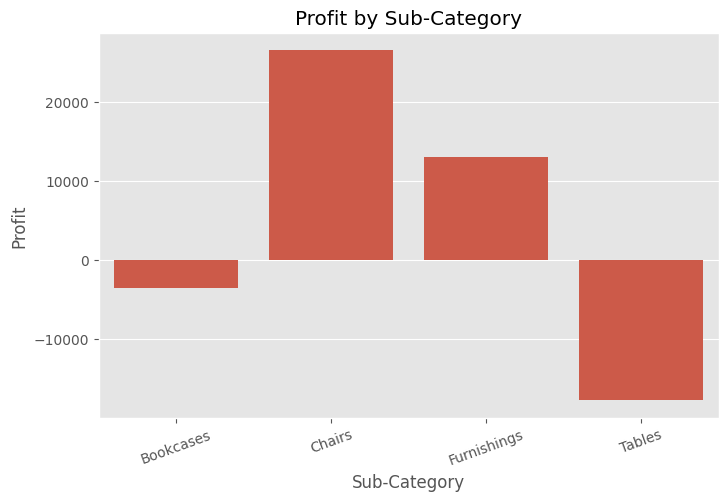

In [31]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=subcategory_profit,
    x="Sub-Category",
    y="Profit"
)

plt.title("Profit by Sub-Category")
plt.xticks(rotation=20)

plt.show()

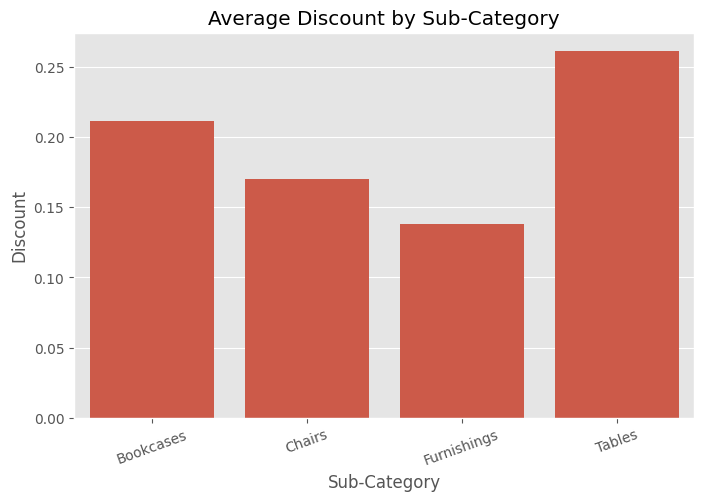

In [32]:
discount = df.groupby("Sub-Category")["Discount"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=discount,
    x="Sub-Category",
    y="Discount"
)

plt.title("Average Discount by Sub-Category")
plt.xticks(rotation=20)

plt.show()

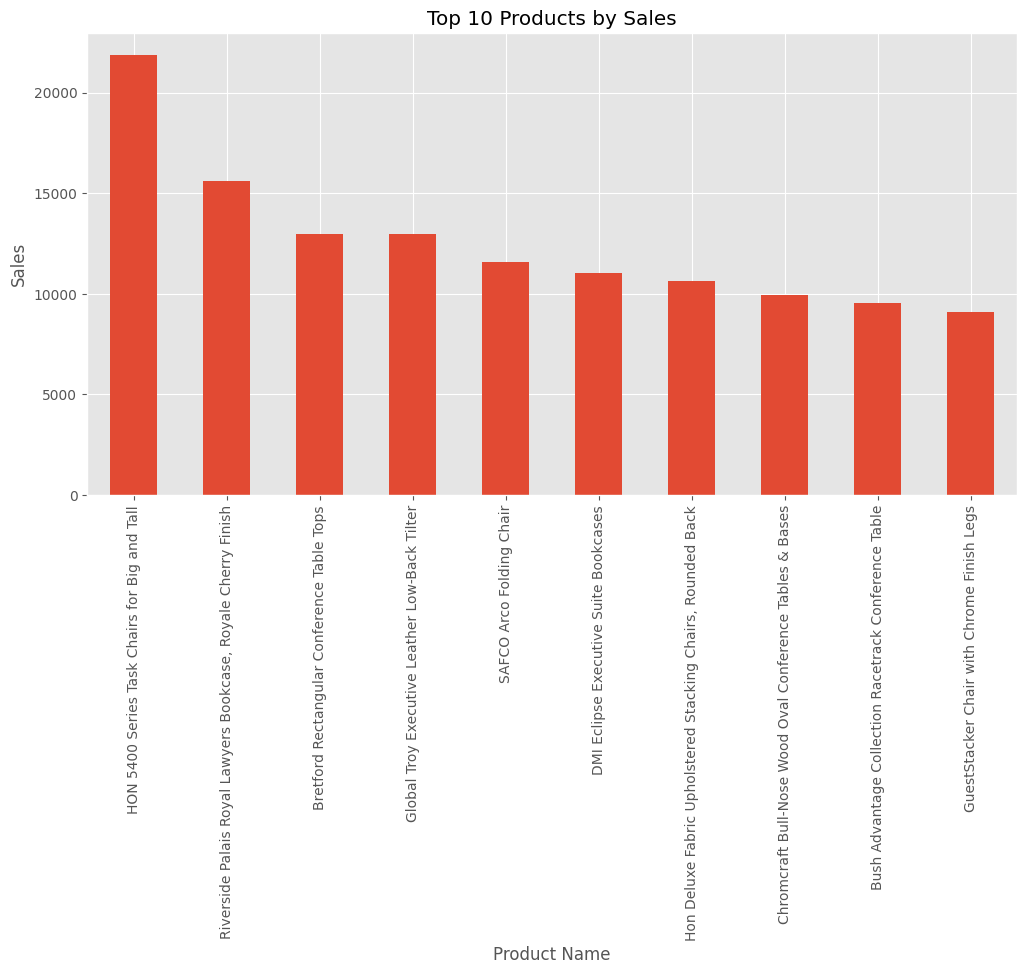

In [33]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13384\1565134143.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


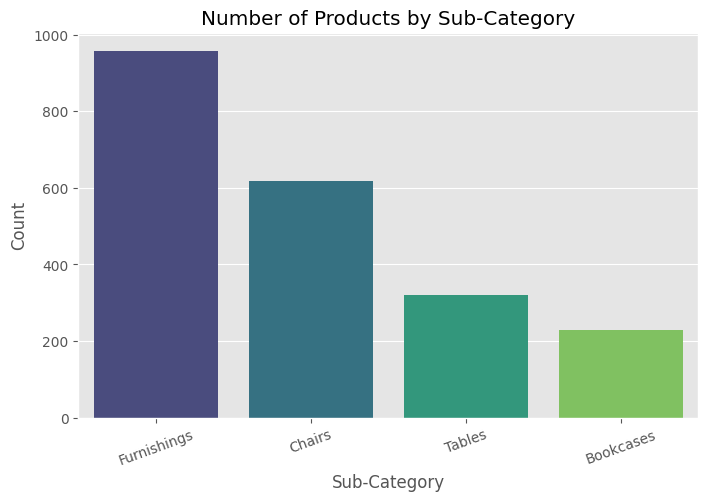

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sub-Category",
    order=df["Sub-Category"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Products by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13384\761211880.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


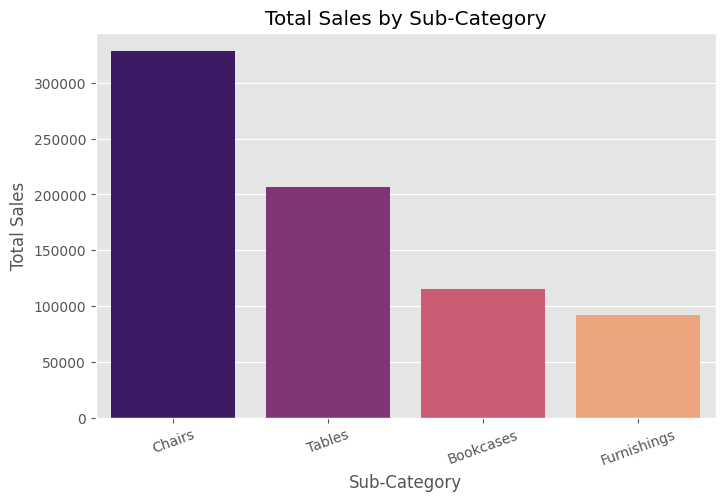

In [38]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=subcategory_sales,
    x="Sub-Category",
    y="Sales",
    palette="magma"
)

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13384\4204126020.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


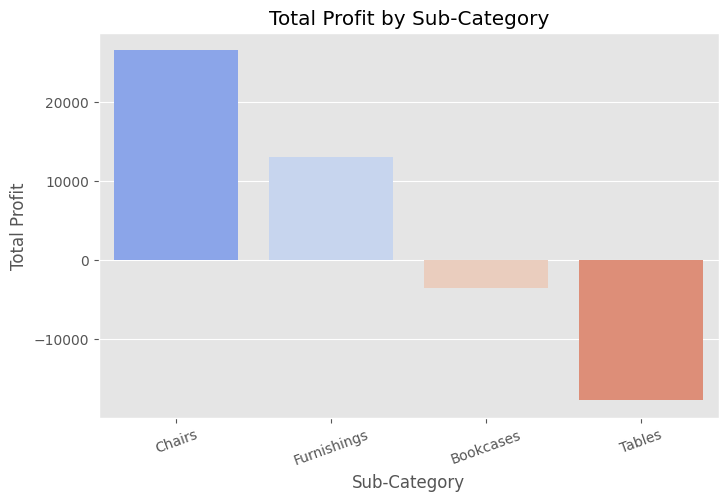

In [39]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=subcategory_profit,
    x="Sub-Category",
    y="Profit",
    palette="coolwarm"
)

plt.title("Total Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=20)

plt.show()


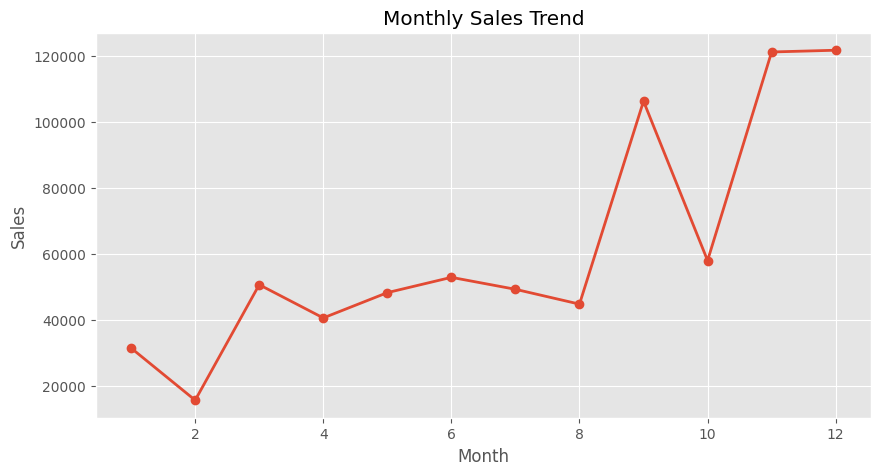

In [40]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13384\2103247215.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


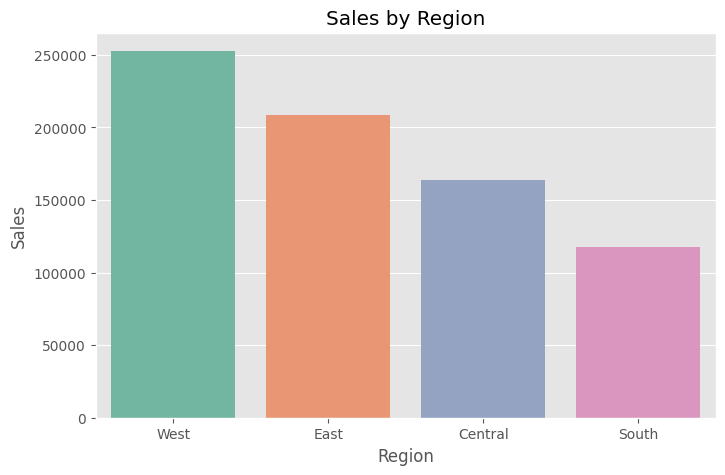

In [41]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales",
    palette="Set2"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

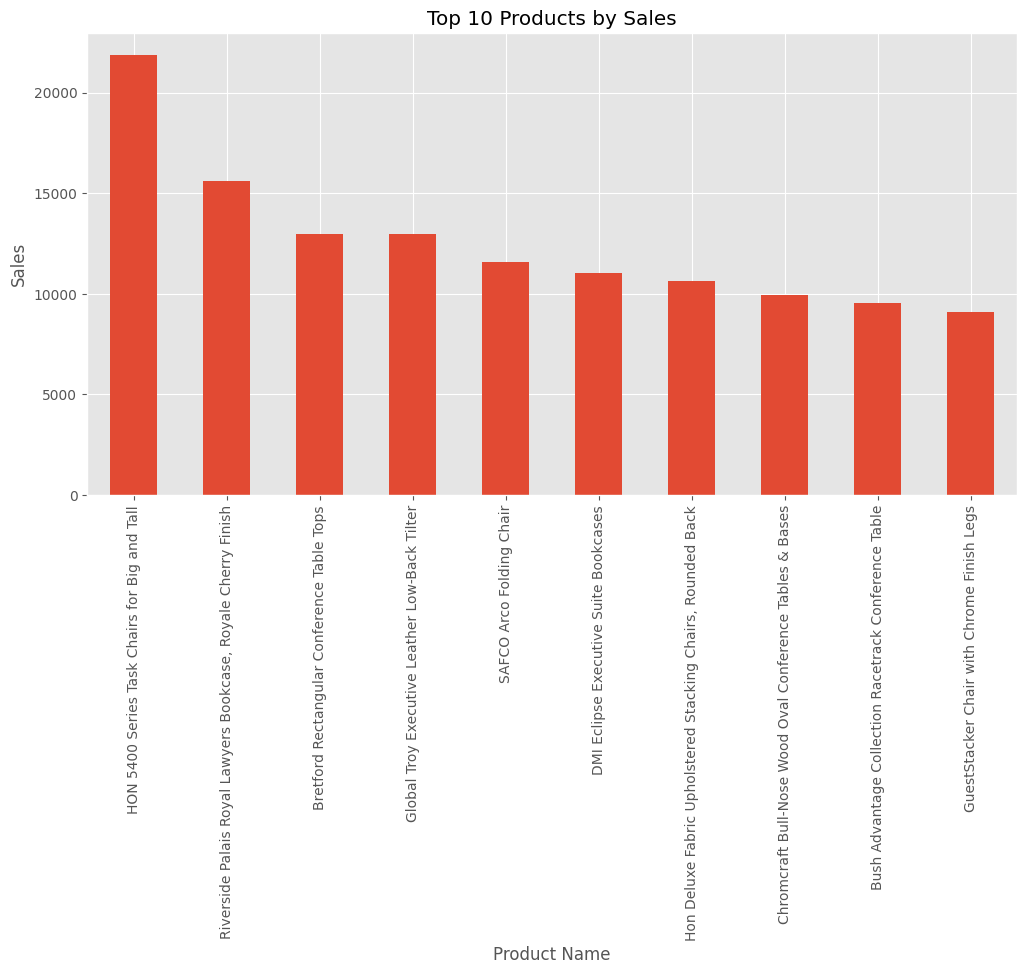

In [42]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.show()

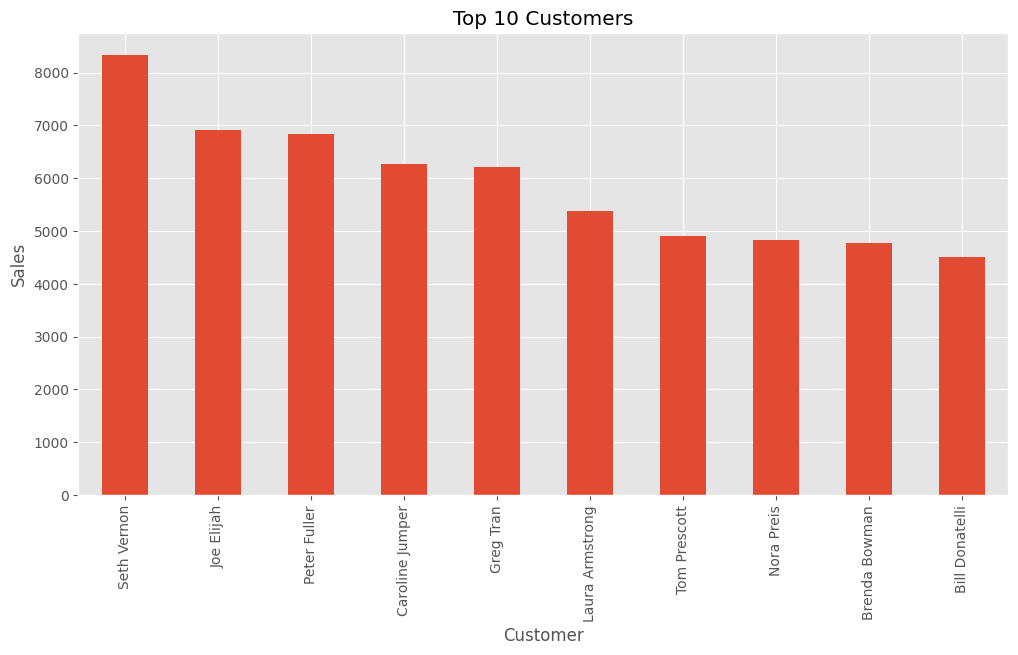

In [43]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

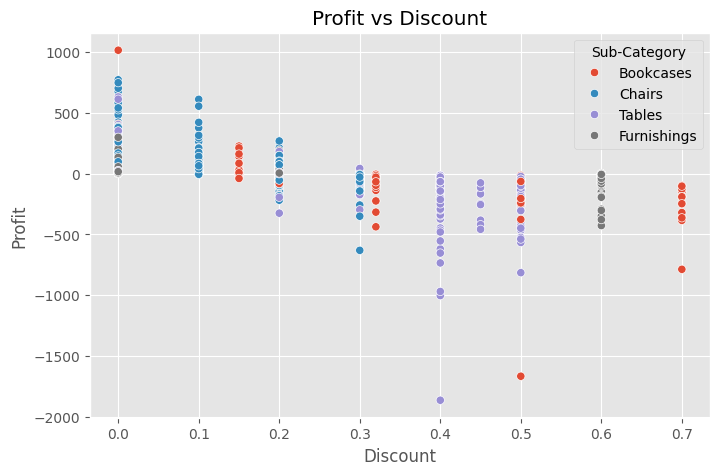

In [44]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Sub-Category"
)

plt.title("Profit vs Discount")

plt.show()

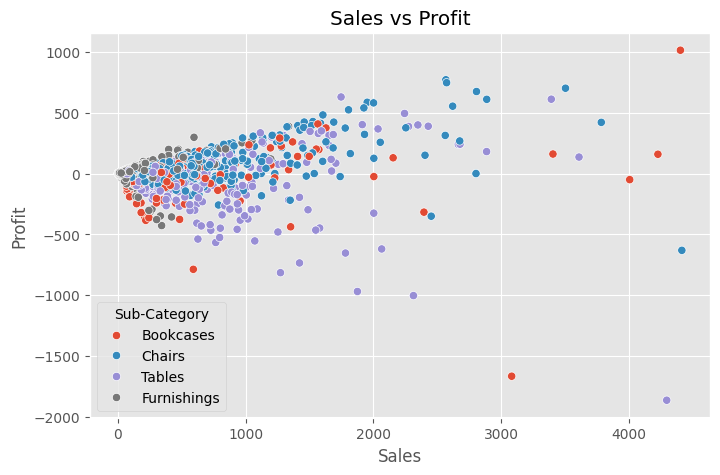

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Sub-Category"
)

plt.title("Sales vs Profit")

plt.show()

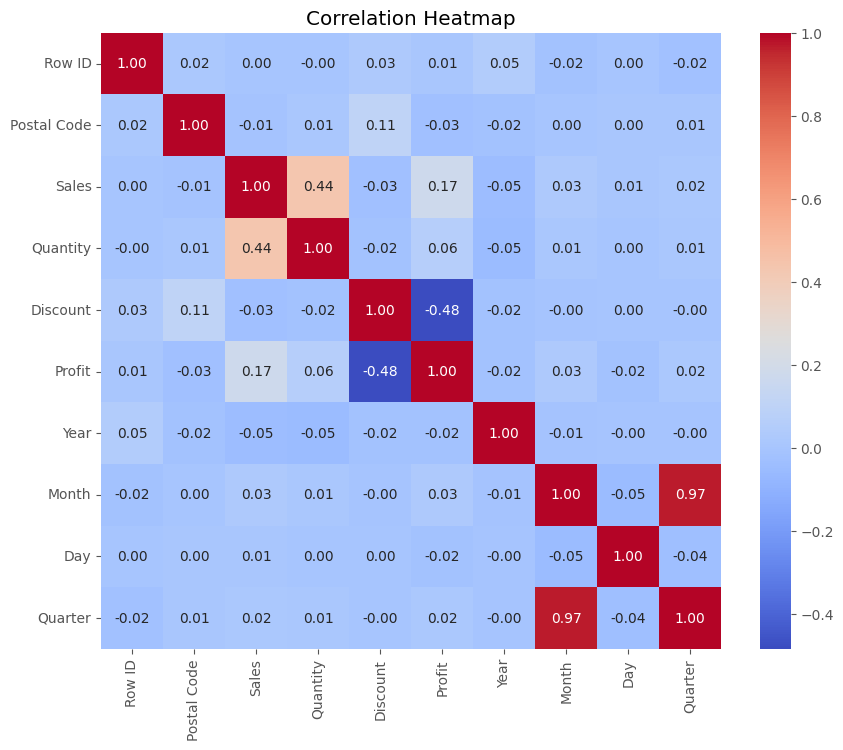

In [46]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

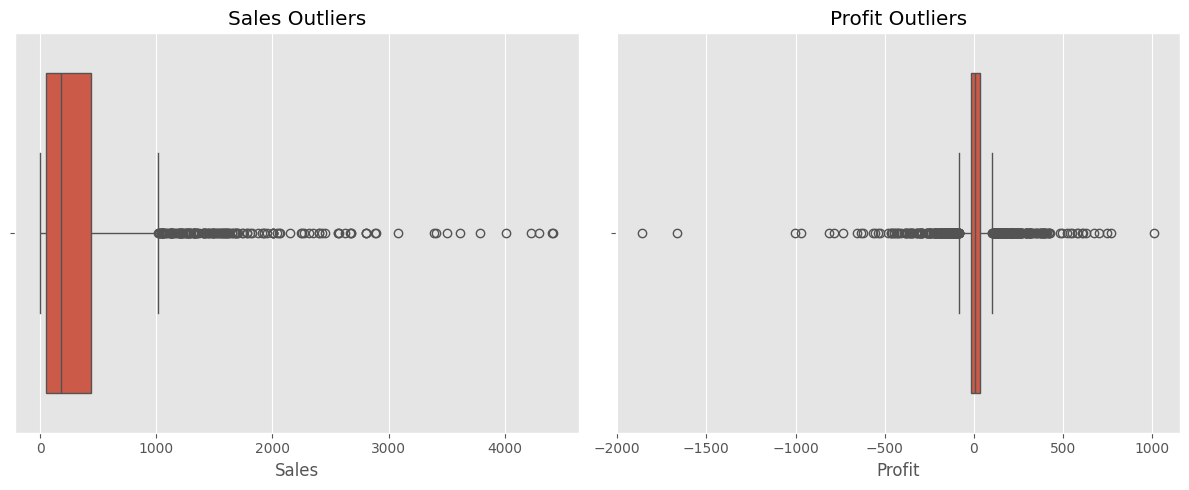

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(x=df["Sales"])

plt.title("Sales Outliers")

plt.subplot(1,2,2)

sns.boxplot(x=df["Profit"])

plt.title("Profit Outliers")

plt.tight_layout()

plt.show()

In [48]:
df.to_csv("../data/clean_sales.csv", index=False)

print("Clean dataset saved successfully!")

print("\nFinal Shape:", df.shape)

display(df.head())

Clean dataset saved successfully!

Final Shape: (2121, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,Tuesday,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,Tuesday,4
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,Sunday,4
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,9,Monday,2
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,9,Monday,2


In [2]:
df.info()


NameError: name 'df' is not defined